<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Household_Expenditures_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel('/content/Household_Expenditures_Data.xlsx')

In [ ]:
df.head(10)

,Household,Groceries,Utilities,Rent,Entertainment
0,H1,8500,3000,12000,2000
1,H2,9200,2800,11500,2500
2,H3,8700,3200,13000,3000
3,H4,7800,3100,11000,1800
4,H5,9600,2900,12500,2700
5,H6,9100,3300,14000,2200
6,H7,8900,3000,13500,2400
7,H8,8500,3100,11500,2100
8,H9,9200,3400,12000,2600
9,H10,8800,3000,12500,2300


In [ ]:
#Find the Total Expense of each household
df["Total_Expense"] = df["Groceries"] + df["Utilities"] + df["Rent"] + df["Entertainment"]
print(df)

  Household  Groceries  Utilities   Rent  Entertainment  Total_Expense
0        H1       8500       3000  12000           2000          25500
1        H2       9200       2800  11500           2500          26000
2        H3       8700       3200  13000           3000          27900
3        H4       7800       3100  11000           1800          23700
4        H5       9600       2900  12500           2700          27700
5        H6       9100       3300  14000           2200          28600
6        H7       8900       3000  13500           2400          27800
7        H8       8500       3100  11500           2100          25200
8        H9       9200       3400  12000           2600          27200
9       H10       8800       3000  12500           2300          26600


In [ ]:
df.head()

,Household,Groceries,Utilities,Rent,Entertainment,Total_Expense
0,H1,8500,3000,12000,2000,25500
1,H2,9200,2800,11500,2500,26000
2,H3,8700,3200,13000,3000,27900
3,H4,7800,3100,11000,1800,23700
4,H5,9600,2900,12500,2700,27700


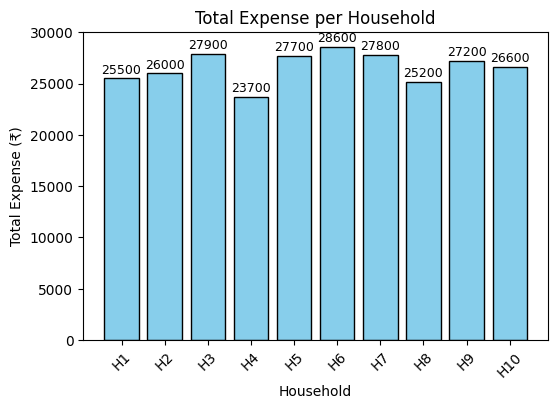

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(df["Household"], df["Total_Expense"], color="skyblue", edgecolor="black")

plt.xlabel("Household")
plt.ylabel("Total Expense (₹)")
plt.title("Total Expense per Household")
plt.xticks(rotation=45)

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200,  # 200 = gap above bar
             f"{yval:.0f}", ha="center", va="bottom", fontsize=9)

plt.show()


In [ ]:
#find the Maximum expense of a particular household
highest_expense = df.loc[df["Total_Expense"].idxmax()]

print("Household with highest expense:")
print(highest_expense)

Household with highest expense:
Household           H6
Groceries         9100
Utilities         3300
Rent             14000
Entertainment     2200
Total_Expense    28600
Name: 5, dtype: object


In [ ]:
#find the Minimum expense of a particular household
highest_expense = df.loc[df["Total_Expense"].idxmin()]

print("Household with highest expense:")
print(highest_expense)

Household with highest expense:
Household           H4
Groceries         7800
Utilities         3100
Rent             11000
Entertainment     1800
Total_Expense    23700
Name: 3, dtype: object


In [ ]:
#Give all statistics information
df.describe()

,Groceries,Utilities,Rent,Entertainment,Total_Expense
count,10.000000,10.00000,10.000000,10.000000,10.00000
mean,8830.000000,3080.00000,12350.000000,2360.000000,26620.00000
std,498.998998,181.35294,944.281032,356.526452,1514.22881
min,7800.000000,2800.00000,11000.000000,1800.000000,23700.00000
25%,8550.000000,3000.00000,11625.000000,2125.000000,25625.00000
50%,8850.000000,3050.00000,12250.000000,2350.000000,26900.00000
75%,9175.000000,3175.00000,12875.000000,2575.000000,27775.00000
max,9600.000000,3400.00000,14000.000000,3000.000000,28600.00000


In [ ]:
#find the ratio of expense/percentage expense
df["Groceries_Ratio"] = (df["Groceries"] / df["Total_Expense"]) * 100
df["Utilities_Ratio"] = (df["Utilities"] / df["Total_Expense"]) * 100
df["Rent_Ratio"] = (df["Rent"] / df["Total_Expense"]) * 100
df["Entertainment_Ratio"] = (df["Entertainment"] / df["Total_Expense"]) * 100

print(df[["Household", "Groceries_Ratio", "Utilities_Ratio", "Rent_Ratio", "Entertainment_Ratio"]])


  Household  Groceries_Ratio  Utilities_Ratio  Rent_Ratio  Entertainment_Ratio
0        H1        33.333333        11.764706   47.058824             7.843137
1        H2        35.384615        10.769231   44.230769             9.615385
2        H3        31.182796        11.469534   46.594982            10.752688
3        H4        32.911392        13.080169   46.413502             7.594937
4        H5        34.657040        10.469314   45.126354             9.747292
5        H6        31.818182        11.538462   48.951049             7.692308
6        H7        32.014388        10.791367   48.561151             8.633094
7        H8        33.730159        12.301587   45.634921             8.333333
8        H9        33.823529        12.500000   44.117647             9.558824
9       H10        33.082707        11.278195   46.992481             8.646617


Overall Expense Ratios (%):
 Groceries        33.170548
Utilities        11.570248
Rent             46.393689
Entertainment     8.865515
dtype: float64


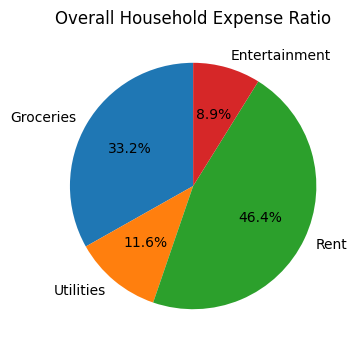

In [ ]:
#Find overall expense ratio/Percentage expense for all household
import matplotlib.pyplot as plt

total_expenses = df[["Groceries", "Utilities", "Rent", "Entertainment"]].sum()

# Calculate overall ratio (percentage share of each category)
total_ratios = (total_expenses / total_expenses.sum()) * 100

print("Overall Expense Ratios (%):\n", total_ratios)

# Plot pie chart
plt.figure(figsize=(4,4))
plt.pie(total_ratios, labels=total_ratios.index, autopct='%1.1f%%', startangle=90)
plt.title("Overall Household Expense Ratio")
plt.show()


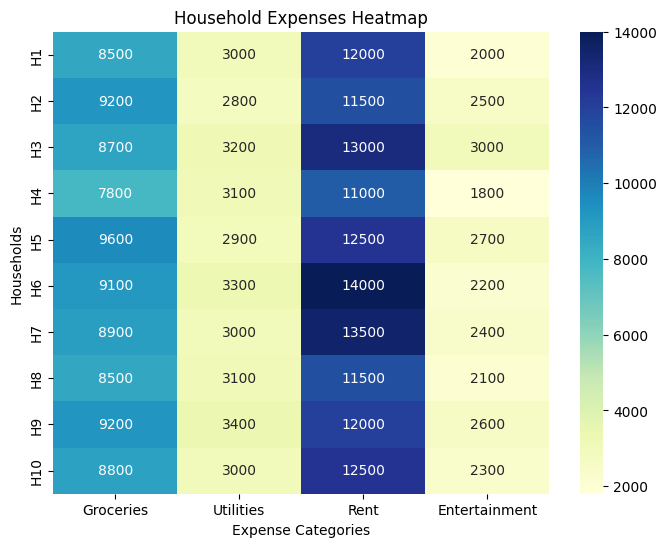

In [ ]:
import seaborn as sns

expense_data = df[["Groceries", "Utilities", "Rent", "Entertainment"]]

# Set Household as index for better visualization
expense_data.index = df["Household"]

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(expense_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar=True)

plt.title("Household Expenses Heatmap")
plt.xlabel("Expense Categories")
plt.ylabel("Households")
plt.show()

In [ ]:
#compare the highest expense household with avg so that we can find why it is high
category_means = df[["Groceries", "Utilities", "Rent", "Entertainment"]].mean()

# Find the household with the highest total expense (which we already know is H6)
highest_expense_household = df.loc[df["Total_Expense"].idxmax()]

print("Average Expense per Category:")
print(category_means)
print("\nHighest Expense Household (H6):")
print(highest_expense_household)

# Compare H6's expenses to the average expenses
print("\nComparison of H6's Expenses to Average Expenses:")
for category in ["Groceries", "Utilities", "Rent", "Entertainment"]:
    h6_expense = highest_expense_household[category]
    average_expense = category_means[category]
    print(f"{category}: H6 - {h6_expense:.0f}, Average - {average_expense:.0f}")

# Identify the category with the largest share of expense for H6
largest_share_category = highest_expense_household[["Groceries", "Utilities", "Rent", "Entertainment"]].idxmax()
largest_share_value = highest_expense_household[largest_share_category]


print(f"\nH6's largest expense category is {largest_share_category} with an expense of {largest_share_value:.0f}.")

# Explain the reason for the high expense based on the comparison
print("\nReason for H6's high total expense:")
if largest_share_value > category_means[largest_share_category]:
    print(f"H6's {largest_share_category} expense ({largest_share_value:.0f}) is significantly higher than the average {largest_share_category} expense across all households ({category_means[largest_share_category]:.0f}). This contributes significantly to H6 having the highest overall expense.")
else:
     print(f"While H6 has the highest total expense, its {largest_share_category} expense ({largest_share_value:.0f}) is not significantly higher than the average {largest_share_category} expense across all households ({category_means[largest_share_category]:.0f}). There might be a combination of factors across different categories contributing to the high total.")

Average Expense per Category:
Groceries         8830.0
Utilities         3080.0
Rent             12350.0
Entertainment     2360.0
dtype: float64

Highest Expense Household (H6):
Household                     H6
Groceries                   9100
Utilities                   3300
Rent                       14000
Entertainment               2200
Total_Expense              28600
Groceries_Ratio        31.818182
Utilities_Ratio        11.538462
Rent_Ratio             48.951049
Entertainment_Ratio     7.692308
Name: 5, dtype: object

Comparison of H6's Expenses to Average Expenses:
Groceries: H6 - 9100, Average - 8830
Utilities: H6 - 3300, Average - 3080
Rent: H6 - 14000, Average - 12350
Entertainment: H6 - 2200, Average - 2360

H6's largest expense category is Rent with an expense of 14000.

Reason for H6's high total expense:
H6's Rent expense (14000) is significantly higher than the average Rent expense across all households (12350). This contributes significantly to H6 having the highest o

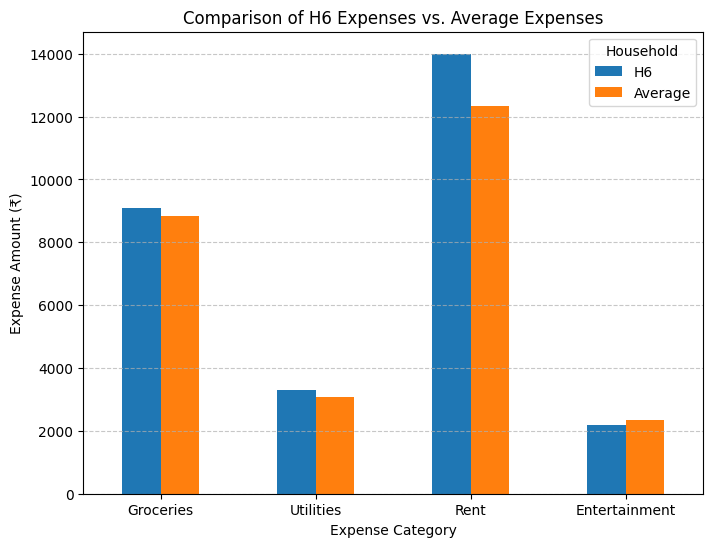

In [ ]:
#chart of the highest expense household with avg
categories = ["Groceries", "Utilities", "Rent", "Entertainment"]
h6_expenses = highest_expense_household[categories]
average_expenses = category_means

# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({
    "H6": h6_expenses,
    "Average": average_expenses
})

# Plotting the bar chart
plot_data.plot(kind="bar", figsize=(8, 6))
plt.title("Comparison of H6 Expenses vs. Average Expenses")
plt.xlabel("Expense Category")
plt.ylabel("Expense Amount (₹)")
plt.xticks(rotation=0)
plt.legend(title="Household")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
#find the correlation with each attribute
correlation_matrix = df[["Groceries", "Utilities", "Rent", "Entertainment", "Total_Expense"]].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
               Groceries  Utilities      Rent  Entertainment  Total_Expense
Groceries       1.000000  -0.103137  0.446854       0.663270       0.752016
Utilities      -0.103137   1.000000  0.272509       0.054991       0.268664
Rent            0.446854   0.272509  1.000000       0.376244       0.892086
Entertainment   0.663270   0.054991  0.376244       1.000000       0.695239
Total_Expense   0.752016   0.268664  0.892086       0.695239       1.000000


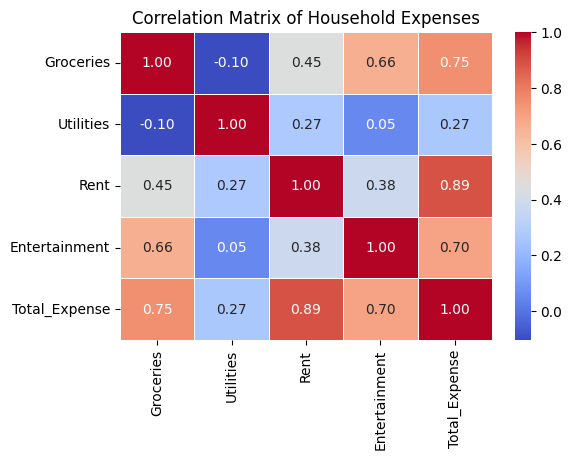

In [ ]:
#chart of correlation and also so that rent is very correlated with the total expense
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Household Expenses")
plt.show()

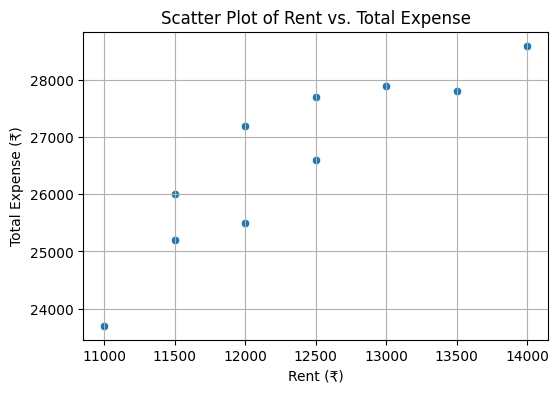

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Rent", y="Total_Expense", data=df)

plt.title("Scatter Plot of Rent vs. Total Expense")
plt.xlabel("Rent (₹)")
plt.ylabel("Total Expense (₹)")
plt.grid(True)
plt.show()

In [ ]:
average_total_expense = df["Total_Expense"].mean()

print(f"Average Total Expense: ₹{average_total_expense:.2f}\n")

# Identify households below the average total expense
households_below_average = df[df["Total_Expense"] < average_total_expense]

print("Households Below Average Total Expense:")
print(households_below_average[["Household", "Total_Expense"]])

# Identify households above the average total expense
households_above_average = df[df["Total_Expense"] >= average_total_expense]

print("\nHouseholds Above or Equal to Average Total Expense:")
print(households_above_average[["Household", "Total_Expense"]])

Average Total Expense: ₹26620.00

Households Below Average Total Expense:
  Household  Total_Expense
0        H1          25500
1        H2          26000
3        H4          23700
7        H8          25200
9       H10          26600

Households Above or Equal to Average Total Expense:
  Household  Total_Expense
2        H3          27900
4        H5          27700
5        H6          28600
6        H7          27800
8        H9          27200
